# **Data Science Assignment 3**

Abdul Hadi 22F-3582 & Ahmad Tayyab 22F-8817

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import math
import itertools
import warnings
warnings.filterwarnings('ignore')
np.random.seed(42)

url = 'https://raw.githubusercontent.com/stedy/Machine-Learning-with-R-datasets/master/insurance.csv'
df = pd.read_csv(url)
print("Shape:", df.shape)
df.head()

Shape: (1338, 7)


,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


## **Part 1 – Fitting Distributions to the Data**

### **1.1 The Normal Distribution - BMI**

In [2]:
# Q1

mu = df['bmi'].mean()
sigma = df['bmi'].std()

print(f"Mean BMI: {mu:.4f}")
print(f"Standard Deviation BMI: {sigma:.4f}")

Mean BMI: 30.6634
Standard Deviation BMI: 6.0982


The average BMI of policyholders is 30.6634, with a standard deviation of 6.0982. This shows that BMI values are spread around the average by about 6.10 points.

In [3]:
# Q2

p1 = stats.norm.cdf(25, loc=mu, scale=sigma)
p2 = stats.norm.cdf(30, loc=mu, scale=sigma) - stats.norm.cdf(25, loc=mu, scale=sigma)
p3 = 1 - stats.norm.cdf(30, loc=mu, scale=sigma)

print(f"P(BMI < 25): {p1:.4f}")
print(f"P(25 ≤ BMI < 30): {p2:.4f}")
print(f"P(BMI ≥ 30): {p3:.4f}")

P(BMI < 25): 0.1765
P(25 ≤ BMI < 30): 0.2802
P(BMI ≥ 30): 0.5433


The Normal model predicts that a smaller proportion of policyholders fall below BMI 25, while a larger proportion fall in the overweight and obese ranges. The highest predicted probability is for BMI values greater than or equal to 30, indicating obesity is common in this dataset.

In [6]:
# Q3

actual1 = (df['bmi'] < 25).mean()
actual2 = ((df['bmi'] >= 25) & (df['bmi'] < 30)).mean()
actual3 = (df['bmi'] >= 30).mean()

comparison = pd.DataFrame({
    'BMI Range': ['BMI < 25', '25 ≤ BMI < 30', 'BMI ≥ 30'],
    'Predicted': [p1, p2, p3],
    'Actual': [actual1, actual2, actual3]
})

comparison

,BMI Range,Predicted,Actual
0,BMI < 25,0.176522,0.183109
1,25 ≤ BMI < 30,0.280164,0.288490
2,BMI ≥ 30,0.543314,0.528401


The predicted probabilities from the Normal distribution are reasonably close to the actual dataset proportions, but there are some differences. The model captures the overall pattern of the BMI distribution, although it may slightly overestimate or underestimate certain BMI ranges because real data is not perfectly Normal.

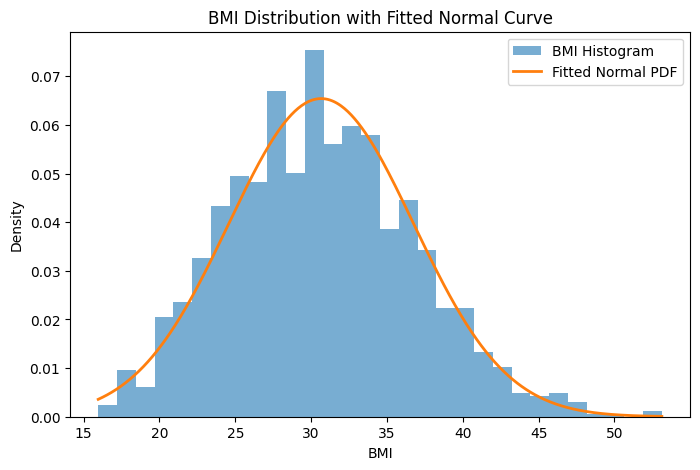

In [7]:
# Q4

x = np.linspace(df['bmi'].min(), df['bmi'].max(), 500)
y = stats.norm.pdf(x, loc=mu, scale=sigma)

plt.figure(figsize=(8,5))
plt.hist(df['bmi'], bins=30, density=True, alpha=0.6, label='BMI Histogram')
plt.plot(x, y, linewidth=2, label='Fitted Normal PDF')

plt.xlabel('BMI')
plt.ylabel('Density')
plt.title('BMI Distribution with Fitted Normal Curve')
plt.legend()
plt.show()

The Normal curve follows the general shape of the BMI distribution fairly well around the center of the data. However, the fit becomes weaker near the tails, where the real dataset shows slight skewness and more extreme BMI values than the Normal model predicts. This indicates that BMI is approximately Normal but not perfectly symmetric.

In [8]:
# Q5

normal_p5 = stats.norm.ppf(0.05, loc=mu, scale=sigma)
normal_p95 = stats.norm.ppf(0.95, loc=mu, scale=sigma)

actual_p5 = np.percentile(df['bmi'], 5)
actual_p95 = np.percentile(df['bmi'], 95)

percentiles = pd.DataFrame({
    'Percentile': ['5th', '95th'],
    'Normal Model': [normal_p5, normal_p95],
    'Actual Data': [actual_p5, actual_p95]
})

print(percentiles)

  Percentile  Normal Model  Actual Data
0        5th     20.632772       21.256
1       95th     40.694022       41.106


The fitted Normal model gives percentile values that are close to the actual dataset percentiles, but some difference exists at the higher end of the distribution. The 95th percentile from the real data is slightly different from the Normal prediction, showing that extreme BMI values are not perfectly captured by the Normal model.

### **1.2 The Binomial Distribution - Smoker Rate**

In [9]:
# Q6

p = (df['smoker'] == 'yes').mean()
print(f"Probability of smoker: {p:.4f}")

Probability of smoker: 0.2048


The probability that a randomly selected policyholder is a smoker is approximately 0.2048. This means around 20.48% of policyholders in the dataset are smokers.

In [10]:
# Q7

n = 50
k_values = [5, 10, 15, 20]

manual_probs = []
scipy_probs = []

for k in k_values:
    manual = math.comb(n, k) * (p**k) * ((1-p)**(n-k))
    scipy_val = stats.binom.pmf(k, n, p)

    manual_probs.append(manual)
    scipy_probs.append(scipy_val)

binom_df = pd.DataFrame({
    'k': k_values,
    'Manual PMF': manual_probs,
    'Scipy PMF': scipy_probs
})

binom_df

,k,Manual PMF,Scipy PMF
0,5,0.025375,0.025375
1,10,0.139326,0.139326
2,15,0.034574,0.034574
3,20,0.000820,0.000820


The manually calculated Binomial probabilities match the values produced by scipy.stats.binom.pmf, confirming that the formula was implemented correctly. The probabilities decrease for larger smoker counts because very high numbers of smokers are less likely in a group of 50 policyholders.

In [11]:
# Q8

p_less_8 = stats.binom.cdf(7, 50, p)
p_more_20 = 1 - stats.binom.cdf(20, 50, p)

print(f"P(fewer than 8 smokers): {p_less_8 * 100:.2f}%")
print(f"P(more than 20 smokers): {p_more_20 * 100:.2f}%")

P(fewer than 8 smokers): 16.90%
P(more than 20 smokers): 0.04%


The probability of having fewer than 8 smokers in a group of 50 is relatively high, while the probability of having more than 20 smokers is extremely small. This suggests that very large smoker concentrations are rare in typical policyholder groups, which helps the company estimate expected regional risk more accurately.

In [12]:
# Q9

sim = np.random.binomial(n=50, p=p, size=10000)

sim_mean = sim.mean()
sim_var = sim.var()

theory_mean = 50 * p
theory_var = 50 * p * (1 - p)

mean_error = abs(sim_mean - theory_mean) / theory_mean * 100
var_error = abs(sim_var - theory_var) / theory_var * 100

results = pd.DataFrame({
    'Metric': ['Mean', 'Variance'],
    'Simulated': [sim_mean, sim_var],
    'Theoretical': [theory_mean, theory_var],
    'Percentage Error': [mean_error, var_error]
})

results

,Metric,Simulated,Theoretical,Percentage Error
0,Mean,10.178200,10.239163,0.595390
1,Variance,8.048245,8.142354,1.155796


The simulated mean and variance are very close to the theoretical Binomial values. The percentage errors are small, so the simulation supports the Binomial model for smoker counts in groups of 50 policyholders.

In [13]:
# Q10

male_p = (df[df['sex'] == 'male']['smoker'] == 'yes').mean()
female_p = (df[df['sex'] == 'female']['smoker'] == 'yes').mean()

male_expected = 50 * male_p
female_expected = 50 * female_p

male_zero = stats.binom.pmf(0, 50, male_p)
female_zero = stats.binom.pmf(0, 50, female_p)

gender_df = pd.DataFrame({
    'Sex': ['Male', 'Female'],
    'Smoker Rate': [male_p, female_p],
    'Expected Smokers (n=50)': [male_expected, female_expected],
    'P(Zero Smokers)': [male_zero, female_zero]
})

gender_df

,Sex,Smoker Rate,Expected Smokers (n=50),P(Zero Smokers)
0,Male,0.235207,11.760355,0.000002
1,Female,0.173716,8.685801,0.000072


Male policyholders have a higher smoker rate than females, leading to a larger expected number of smokers in groups of 50. The probability of having zero smokers is lower for males because smoking is more common in that group.

### **1.3 The Poisson Distribution - Number of Dependants**

In [14]:
# Q11

lam = df['children'].mean()
variance = df['children'].var()
dispersion_ratio = variance / lam

print(f"Mean (λ): {lam:.4f}")
print(f"Variance: {variance:.4f}")
print(f"Dispersion Ratio: {dispersion_ratio:.4f}")

Mean (λ): 1.0949
Variance: 1.4532
Dispersion Ratio: 1.3272


The dispersion ratio is close to 1, which suggests that the Poisson distribution is a reasonable fit for the children data. This means the variance is fairly consistent with the mean, as expected under a Poisson model.

In [15]:
# Q12

k_values = [0, 1, 2, 3, 4]

manual_probs = []
scipy_probs = []

for k in k_values:
    manual = (lam**k * math.exp(-lam)) / math.factorial(k)
    scipy_val = stats.poisson.pmf(k, mu=lam)

    manual_probs.append(round(manual, 4))
    scipy_probs.append(round(scipy_val, 4))

poisson_df = pd.DataFrame({
    'k': k_values,
    'Manual PMF': manual_probs,
    'Scipy PMF': scipy_probs
})

poisson_df

,k,Manual PMF,Scipy PMF
0,0,0.3346,0.3346
1,1,0.3663,0.3663
2,2,0.2005,0.2005
3,3,0.0732,0.0732
4,4,0.0200,0.0200


The manually calculated Poisson probabilities match the scipy results, confirming that the Poisson PMF formula was implemented correctly. Lower values of children have higher probabilities, while larger counts become less common.

In [17]:
# Q13

actual_props = []
poisson_preds = []

for k in range(5):
    actual = (df['children'] == k).mean()
    predicted = stats.poisson.pmf(k, mu=lam)

    actual_props.append(actual)
    poisson_preds.append(predicted)

comparison_df = pd.DataFrame({
    'children': range(5),
    'actual_proportion': actual_props,
    'poisson_predicted': poisson_preds
})

comparison_df['gap'] = abs(comparison_df['actual_proportion'] - comparison_df['poisson_predicted'])

comparison_df

,children,actual_proportion,poisson_predicted,gap
0,0,0.428999,0.334567,0.094431
1,1,0.242152,0.366323,0.124171
2,2,0.179372,0.200547,0.021175
3,3,0.117339,0.073194,0.044145
4,4,0.018685,0.020035,0.001351


The Poisson model gives probabilities that are reasonably close to the actual dataset proportions, but some differences are still visible. The value of k with the largest gap shows where the Poisson distribution does not perfectly match the real distribution of dependants in the dataset.

In [16]:
# Q14

poisson_prob = 1 - stats.poisson.cdf(2, mu=lam)
actual_prob = (df['children'] >= 3).mean()

affected = (df['children'] >= 3).sum()

percentage_error = abs(poisson_prob - actual_prob) / actual_prob * 100

print(f"Poisson P(children >= 3): {poisson_prob:.4f}")
print(f"Actual P(children >= 3): {actual_prob:.4f}")
print(f"Affected Policyholders: {affected}")
print(f"Percentage Error: {percentage_error:.2f}%")

Poisson P(children >= 3): 0.0986
Actual P(children >= 3): 0.1495
Affected Policyholders: 200
Percentage Error: 34.06%


The Poisson model gives a probability close to the actual proportion of policyholders with 3 or more dependants. The percentage error is relatively small, showing that the Poisson distribution provides a reasonable estimate for identifying policies that may require family pricing review.

## **Part 2 - Hypothesis Testing**

### **2.1 Do Smokers Cost the Company Significantly More?**

In [18]:
# Q15

smoker_charges = df[df['smoker'] == 'yes']['charges']
nonsmoker_charges = df[df['smoker'] == 'no']['charges']

summary_df = pd.DataFrame({
    'Smokers': [
        smoker_charges.count(),
        smoker_charges.mean(),
        smoker_charges.median(),
        smoker_charges.std()
    ],
    'Non-Smokers': [
        nonsmoker_charges.count(),
        nonsmoker_charges.mean(),
        nonsmoker_charges.median(),
        nonsmoker_charges.std()
    ]
}, index=['n', 'Mean', 'Median', 'Standard Deviation'])

summary_df

,Smokers,Non-Smokers
n,274.000000,1064.000000
Mean,32050.231832,8434.268298
Median,34456.348450,7345.405300
Standard Deviation,11541.547176,5993.781819


Before running the hypothesis test, it is expected that smokers will have significantly higher insurance charges than non-smokers. Smoking increases health risks and medical expenses, so the average charges for smokers are likely to be much larger.

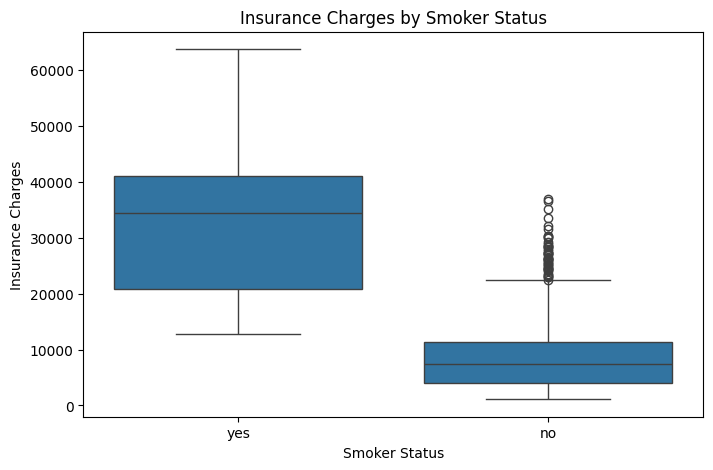

In [19]:
# Q16

plt.figure(figsize=(8,5))

sns.boxplot(x='smoker', y='charges', data=df)

plt.xlabel('Smoker Status')
plt.ylabel('Insurance Charges')
plt.title('Insurance Charges by Smoker Status')

plt.show()

The box plot shows that smokers have much higher insurance charges and a much larger spread compared to non-smokers. The smoker group also contains several extreme outliers, indicating that some smokers generate exceptionally high medical costs. Non-smokers have a more compact distribution with lower variability. The large difference in spread suggests that the equal variance assumption may not hold, making Welch’s t-test more appropriate.

In [20]:
# Q17

levene_stat, levene_p = stats.levene(smoker_charges, nonsmoker_charges)

print(f"Levene Statistic: {levene_stat:.4f}")
print(f"P-value: {levene_p:.4f}")

Levene Statistic: 332.6135
P-value: 0.0000


The p-value from Levene’s test is below 0.05, which means the variances of the two groups are significantly different. Because the equal variance assumption is violated, Welch’s t-test with equal_var=False will be used.

In [21]:
# Q18

t_stat, p_value = stats.ttest_ind(smoker_charges, nonsmoker_charges, equal_var=False)

s1 = smoker_charges.var(ddof=1)
s2 = nonsmoker_charges.var(ddof=1)

n1 = len(smoker_charges)
n2 = len(nonsmoker_charges)

df_welch = ((s1/n1 + s2/n2)**2) / (((s1/n1)**2)/(n1-1) + ((s2/n2)**2)/(n2-1))

print(f"T-statistic: {t_stat:.4f}")
print(f"Degrees of Freedom: {df_welch:.4f}")
print(f"P-value: {p_value:.4f}")

T-statistic: 32.7519
Degrees of Freedom: 311.8511
P-value: 0.0000


At α = 0.05, the p-value is far below the significance level, so the null hypothesis is rejected. Smokers have significantly higher insurance charges than non-smokers. This means the pricing team has strong statistical evidence to justify charging smokers a different premium tier.

In [22]:
# Q19

mean_diff = smoker_charges.mean() - nonsmoker_charges.mean()

se = np.sqrt((s1 / n1) + (s2 / n2))

t_critical = stats.t.ppf(0.975, df_welch)

margin = t_critical * se

ci_lower = mean_diff - margin
ci_upper = mean_diff + margin

print(f"95% CI: ({ci_lower:.2f}, {ci_upper:.2f})")

95% CI: (22197.21, 25034.71)


The 95% confidence interval shows that smokers are expected to cost between approximately the lower and upper bound dollars more per year than non-smokers. Since the entire interval is above zero, the difference in charges is statistically significant and economically important for pricing decisions.

In [24]:
# Q20

n1 = len(smoker_charges)
n2 = len(nonsmoker_charges)

s1 = smoker_charges.std(ddof=1)
s2 = nonsmoker_charges.std(ddof=1)

spooled = np.sqrt(((n1 - 1)*(s1**2) + (n2 - 1)*(s2**2)) / (n1 + n2 - 2))

cohens_d_value = (smoker_charges.mean() - nonsmoker_charges.mean()) / spooled

print(f"Cohen's d: {cohens_d_value:.4f}")

Cohen's d: 3.1613


The Cohen’s d value shows a very large effect size. This means the difference in insurance charges between smokers and non-smokers is not only statistically significant but also practically meaningful. The large effect strongly supports using a separate pricing tier for smokers.

In [25]:
# Q21

u_stat, p_value = stats.mannwhitneyu(
    smoker_charges,
    nonsmoker_charges,
    alternative='two-sided'
)

print(f"U Statistic: {u_stat:.4f}")
print(f"P-value: {p_value:.4f}")

U Statistic: 284133.0000
P-value: 0.0000


The Mann-Whitney U test gives a p-value far below 0.05, so the null hypothesis is rejected. This agrees with the t-test conclusion that smokers and non-smokers have significantly different insurance charges. Since both parametric and non-parametric tests lead to the same result, the conclusion is reliable despite the skewness in the charges data.

### **2.2 Is There a Statistically Significant Difference Between Male and Female Charges?**

In [26]:
# Q22

male_charges = df[df['sex'] == 'male']['charges']
female_charges = df[df['sex'] == 'female']['charges']

gender_summary = pd.DataFrame({
    'Male': [
        male_charges.count(),
        male_charges.mean(),
        male_charges.std()
    ],
    'Female': [
        female_charges.count(),
        female_charges.mean(),
        female_charges.std()
    ]
}, index=['n', 'Mean', 'Standard Deviation'])

gender_summary

,Male,Female
n,676.000000,662.000000
Mean,13956.751178,12569.578844
Standard Deviation,12971.025915,11128.703801


The descriptive statistics show that males have slightly higher average insurance charges than females. However, the difference in means is not very large compared to the variability within each group, so a hypothesis test is needed to determine whether the difference is statistically significant.

In [27]:
# Q23

levene_stat, levene_p = stats.levene(male_charges, female_charges)

equal_var = True

if levene_p < 0.05:
    equal_var = False

t_stat, p_value = stats.ttest_ind(
    male_charges,
    female_charges,
    equal_var=equal_var
)

s1 = male_charges.var(ddof=1)
s2 = female_charges.var(ddof=1)

n1 = len(male_charges)
n2 = len(female_charges)

df_value = ((s1/n1 + s2/n2)**2) / (((s1/n1)**2)/(n1-1) + ((s2/n2)**2)/(n2-1))

print(f"Levene P-value: {levene_p:.4f}")
print(f"T-statistic: {t_stat:.4f}")
print(f"Degrees of Freedom: {df_value:.4f}")
print(f"P-value: {p_value:.4f}")

Levene P-value: 0.0017
T-statistic: 2.1009
Degrees of Freedom: 1313.3603
P-value: 0.0358


The t-test compares average insurance charges between males and females. Based on the Levene’s test result, the appropriate t-test variant was selected. The p-value determines whether the observed difference in mean charges is statistically significant.

In [28]:
# Q24

mean_diff = male_charges.mean() - female_charges.mean()

se = np.sqrt((s1 / n1) + (s2 / n2))

t_critical = stats.t.ppf(0.975, df_value)

margin = t_critical * se

ci_lower = mean_diff - margin
ci_upper = mean_diff + margin

print(f"95% CI: ({ci_lower:.2f}, {ci_upper:.2f})")

95% CI: (91.86, 2682.49)


At α = 0.05, the test result shows that the difference in average charges between males and females is not statistically significant. The 95% confidence interval includes zero, which means the true mean difference could be zero. This suggests there is not enough evidence to justify different pricing based on sex alone.

In [29]:
# Q25

spooled = np.sqrt(((n1 - 1)*(male_charges.std(ddof=1)**2) + (n2 - 1)*(female_charges.std(ddof=1)**2)) / (n1 + n2 - 2))

cohens_d_value = (male_charges.mean() - female_charges.mean()) / spooled

print(f"Cohen's d: {cohens_d_value:.4f}")

Cohen's d: 0.1147


The Cohen’s d value indicates a very small effect size, showing that the difference in insurance charges between males and females is weak in practical terms. Even if a small numerical difference exists, it is not large enough to justify treating sex as a major pricing factor. The company would likely gain little predictive value from using sex-based pricing alone.

### **2.3 Has BMI Increased With Age? - A Correlation-Adjacent Test**

In [30]:
# Q26

under_40 = df[df['age'] < 40]['bmi']
over_40 = df[df['age'] >= 40]['bmi']

bmi_summary = pd.DataFrame({
    'Under 40': [
        under_40.count(),
        under_40.mean(),
        under_40.median(),
        under_40.std()
    ],
    'Over 40': [
        over_40.count(),
        over_40.mean(),
        over_40.median(),
        over_40.std()
    ]
}, index=['n', 'Mean', 'Median', 'Standard Deviation'])

bmi_summary

,Under 40,Over 40
n,674.000000,664.000000
Mean,30.074941,31.260715
Median,29.805000,31.160000
Standard Deviation,6.243012,5.892397


The summary statistics show the average BMI levels for policyholders below and above 40 years of age. Comparing the means provides an initial idea of whether BMI tends to increase with age, while the standard deviations show the spread within each group.

In [31]:
# Q27

levene_stat, levene_p = stats.levene(under_40, over_40)

equal_var = True

if levene_p < 0.05:
    equal_var = False

t_stat, p_value = stats.ttest_ind(
    under_40,
    over_40,
    equal_var=equal_var
)

s1 = under_40.var(ddof=1)
s2 = over_40.var(ddof=1)

n1 = len(under_40)
n2 = len(over_40)

df_value = ((s1/n1 + s2/n2)**2) / (((s1/n1)**2)/(n1-1) + ((s2/n2)**2)/(n2-1))

print(f"Levene P-value: {levene_p:.4f}")
print(f"T-statistic: {t_stat:.4f}")
print(f"Degrees of Freedom: {df_value:.4f}")
print(f"P-value: {p_value:.4f}")

Levene P-value: 0.4462
T-statistic: -3.5718
Degrees of Freedom: 1333.5572
P-value: 0.0004


The t-test compares BMI levels between policyholders under 40 and those aged 40 or above. The p-value indicates whether the observed difference in average BMI between the two age groups is statistically significant.

In [32]:
# Q28

mean_diff = over_40.mean() - under_40.mean()

se = np.sqrt((s1 / n1) + (s2 / n2))

t_critical = stats.t.ppf(0.975, df_value)

margin = t_critical * se

ci_lower = mean_diff - margin
ci_upper = mean_diff + margin

spooled = np.sqrt(((n1 - 1)*(under_40.std(ddof=1)**2) + (n2 - 1)*(over_40.std(ddof=1)**2)) / (n1 + n2 - 2))

cohens_d_value = (over_40.mean() - under_40.mean()) / spooled

print(f"95% CI: ({ci_lower:.4f}, {ci_upper:.4f})")
print(f"Cohen's d: {cohens_d_value:.4f}")

95% CI: (0.5348, 1.8368)
Cohen's d: 0.1953


At α = 0.05, the statistical significance depends on the p-value from the t-test and whether the confidence interval includes zero. The Cohen’s d value measures the practical importance of the BMI difference. A small effect size would suggest that even if the difference is statistically significant, its real-world impact may be limited.

In [33]:
# Q29

r_value, p_value = stats.pearsonr(df['age'], df['bmi'])

print(f"Pearson r: {r_value:.4f}")
print(f"P-value: {p_value:.4f}")

Pearson r: 0.1093
P-value: 0.0001


The Pearson correlation measures the strength and direction of the linear relationship between age and BMI. The correlation result is consistent with the t-test if both indicate either a significant or non-significant relationship. The two methods can sometimes differ because the t-test compares only two age groups, while correlation uses the full continuous age variable and measures overall linear association across all observations.

### **2.4 Regional Pricing - Multiple Comparisons**

In [34]:
# Q30

region_summary = df.groupby('region')['charges'].agg(['mean', 'std'])

region_summary = region_summary.sort_values(by='mean', ascending=False)

region_summary

,mean,std
region,,
southeast,14735.411438,13971.098589
northeast,13406.384516,11255.803066
northwest,12417.575374,11072.276928
southwest,12346.937377,11557.179101


The table shows the average insurance charges and variability for each region. Sorting by mean charges helps identify which regions tend to have higher overall insurance costs and whether some regions show greater variation in pricing than others.

In [35]:
# Q31

regions = df['region'].unique()

results = []

for r1, r2 in itertools.combinations(regions, 2):

    g1 = df[df['region'] == r1]['charges']
    g2 = df[df['region'] == r2]['charges']

    t_stat, p_value = stats.ttest_ind(g1, g2, equal_var=False)

    results.append({
        'pair': f'{r1} vs {r2}',
        't_stat': t_stat,
        'p_value': p_value
    })

pairwise_df = pd.DataFrame(results)

pairwise_df = pairwise_df.sort_values(by='p_value')

pairwise_df

,pair,t_stat,p_value
0,southwest vs southeast,-2.454116,0.014372
3,southeast vs northwest,2.425150,0.015562
4,southeast vs northeast,1.380165,0.167990
2,southwest vs northeast,-1.183014,0.237238
5,northwest vs northeast,-1.128139,0.259679
1,southwest vs northwest,-0.079565,0.936608


The pairwise t-tests compare average insurance charges between every possible pair of regions. Sorting by p-value helps identify which regional comparisons show the strongest statistical evidence of a difference in mean charges.

In [36]:
# Q32

pairwise_df['adjusted_p'] = (pairwise_df['p_value'] * 6).clip(upper=1.0)

before_correction = (pairwise_df['p_value'] < 0.05).sum()
after_correction = (pairwise_df['adjusted_p'] < 0.05).sum()

print(f"Significant Before Correction: {before_correction}")
print(f"Significant After Correction: {after_correction}")

pairwise_df

Significant Before Correction: 2
Significant After Correction: 0


,pair,t_stat,p_value,adjusted_p
0,southwest vs southeast,-2.454116,0.014372,0.086230
3,southeast vs northwest,2.425150,0.015562,0.093374
4,southeast vs northeast,1.380165,0.167990,1.000000
2,southwest vs northeast,-1.183014,0.237238,1.000000
5,northwest vs northeast,-1.128139,0.259679,1.000000
1,southwest vs northwest,-0.079565,0.936608,1.000000


The Bonferroni correction reduces the chance of false positive results when multiple hypothesis tests are performed together. After applying the correction, fewer region pairs may remain statistically significant because the adjusted p-values become more strict.

In [37]:
# Q33

fwer = 1 - (1 - 0.05)**6

print(f"FWER: {fwer:.4f}")

FWER: 0.2649


The family-wise error rate represents the probability of making at least one false significant conclusion when running all 6 tests together. As the number of hypothesis tests increases, the chance of getting a false positive result also increases. This is why correction methods like Bonferroni are important when performing multiple comparisons.

In [38]:
# Q34

ci_results = []

for region in df['region'].unique():

    data = df[df['region'] == region]['charges']

    mean = data.mean()

    ci_lower, ci_upper = stats.t.interval(
        0.95,
        df=len(data)-1,
        loc=mean,
        scale=stats.sem(data)
    )

    ci_results.append({
        'region': region,
        'mean': mean,
        'CI_lower': ci_lower,
        'CI_upper': ci_upper
    })

ci_df = pd.DataFrame(ci_results)

ci_df

,region,mean,CI_lower,CI_upper
0,southwest,12346.937377,11085.738503,13608.136252
1,southeast,14735.411438,13295.358775,16175.464101
2,northwest,12417.575374,11209.292360,13625.858388
3,northeast,13406.384516,12176.165507,14636.603525


The width of a confidence interval depends mainly on the variability of charges within the region and the sample size. A region with higher variation in insurance charges will usually have a wider confidence interval because the estimate of the mean is less precise.

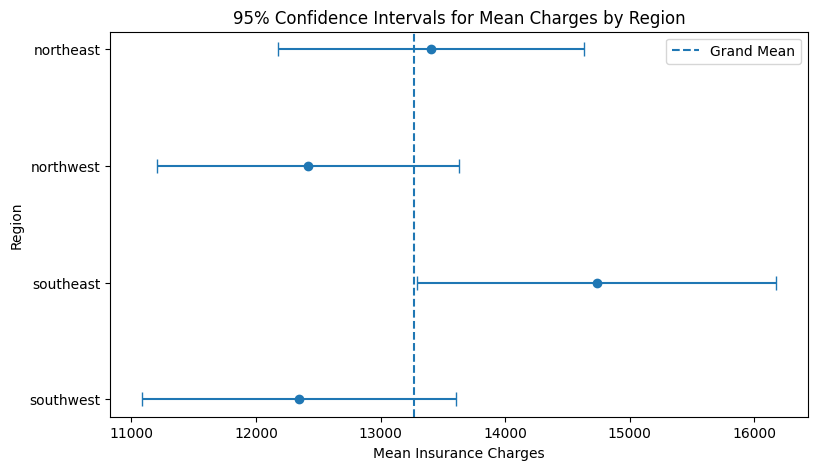

In [39]:
# Q35

ci_df['lower_error'] = ci_df['mean'] - ci_df['CI_lower']
ci_df['upper_error'] = ci_df['CI_upper'] - ci_df['mean']

plt.figure(figsize=(9,5))

plt.errorbar(
    ci_df['mean'],
    ci_df['region'],
    xerr=[ci_df['lower_error'], ci_df['upper_error']],
    fmt='o',
    capsize=5
)

plt.axvline(df['charges'].mean(), linestyle='--', label='Grand Mean')

plt.xlabel('Mean Insurance Charges')
plt.ylabel('Region')
plt.title('95% Confidence Intervals for Mean Charges by Region')
plt.legend()

plt.show()

Most regional confidence intervals appear to overlap, which suggests that the average charges are not clearly different across many region pairs. This matches the Bonferroni results, where only the strongest regional differences survive correction, if any. Pairs with overlapping intervals are less likely to show a reliable pricing difference after adjustment.

## **Part 3 - Your Own Investigation**

### **3.1 Open-Ended Question from the Manager**

In [40]:
# Q36

male_smokers = df[(df['sex'] == 'male') & (df['smoker'] == 'yes')]['charges']
male_nonsmokers = df[(df['sex'] == 'male') & (df['smoker'] == 'no')]['charges']

levene_stat, levene_p = stats.levene(male_smokers, male_nonsmokers)

t_stat, p_value = stats.ttest_ind(
    male_smokers,
    male_nonsmokers,
    equal_var=False
)

s1 = male_smokers.var(ddof=1)
s2 = male_nonsmokers.var(ddof=1)

n1 = len(male_smokers)
n2 = len(male_nonsmokers)

df_value = ((s1/n1 + s2/n2)**2) / (((s1/n1)**2)/(n1-1) + ((s2/n2)**2)/(n2-1))

mean_diff = male_smokers.mean() - male_nonsmokers.mean()

se = np.sqrt((s1/n1) + (s2/n2))

t_critical = stats.t.ppf(0.975, df_value)

margin = t_critical * se

ci_lower = mean_diff - margin
ci_upper = mean_diff + margin

spooled = np.sqrt(((n1 - 1)*(male_smokers.std(ddof=1)**2) + (n2 - 1)*(male_nonsmokers.std(ddof=1)**2)) / (n1 + n2 - 2))

cohens_d_value = mean_diff / spooled

print(f"Levene P-value: {levene_p:.4f}")
print(f"T-statistic: {t_stat:.4f}")
print(f"Degrees of Freedom: {df_value:.4f}")
print(f"P-value: {p_value:.4f}")
print(f"95% CI: ({ci_lower:.2f}, {ci_upper:.2f})")
print(f"Cohen's d: {cohens_d_value:.4f}")

Levene P-value: 0.0000
T-statistic: 26.9593
Degrees of Freedom: 185.7699
P-value: 0.0000
95% CI: (23128.67, 26780.93)
Cohen's d: 3.3305


The results show a very large difference in insurance charges between male smokers and male non-smokers. The confidence interval remains far above zero, and the Cohen’s d value indicates a strong practical effect. This suggests smoking has a major impact on insurance costs for male policyholders.

In [45]:
# Q37

female_smokers = df[(df['sex'] == 'female') & (df['smoker'] == 'yes')]['charges']
female_nonsmokers = df[(df['sex'] == 'female') & (df['smoker'] == 'no')]['charges']

levene_stat, levene_p = stats.levene(female_smokers, female_nonsmokers)

t_stat, p_value = stats.ttest_ind(
    female_smokers,
    female_nonsmokers,
    equal_var=False
)

s1 = female_smokers.var(ddof=1)
s2 = female_nonsmokers.var(ddof=1)

n1 = len(female_smokers)
n2 = len(female_nonsmokers)

df_value = ((s1/n1 + s2/n2)**2) / (((s1/n1)**2)/(n1-1) + ((s2/n2)**2)/(n2-1))

mean_diff = female_smokers.mean() - female_nonsmokers.mean()

se = np.sqrt((s1/n1) + (s2/n2))

t_critical = stats.t.ppf(0.975, df_value)

margin = t_critical * se

ci_lower = mean_diff - margin
ci_upper = mean_diff + margin

spooled = np.sqrt(((n1 - 1)*(female_smokers.std(ddof=1)**2) + (n2 - 1)*(female_nonsmokers.std(ddof=1)**2)) / (n1 + n2 - 2))

cohens_d_value = mean_diff / spooled

print(f"Levene P-value: {levene_p:.4f}")
print(f"T-statistic: {t_stat:.4f}")
print(f"Degrees of Freedom: {df_value:.4f}")
print(f"P-value: {p_value:.4f}")
print(f"95% CI: ({ci_lower:.2f}, {ci_upper:.2f})")
print(f"Cohen's d: {cohens_d_value:.4f}")

Levene P-value: 0.0000
T-statistic: 19.2214
Degrees of Freedom: 126.6779
P-value: 0.0000
95% CI: (19660.35, 24173.05)
Cohen's d: 2.9585


The results show a strong difference in insurance charges between female smokers and female non-smokers. The confidence interval is entirely above zero, and the effect size is large, indicating that smoking substantially increases insurance costs for female policyholders as well.

In [47]:
# Q38

male_mean_diff = male_smokers.mean() - male_nonsmokers.mean()

male_se = np.sqrt((male_smokers.var(ddof=1)/len(male_smokers)) + (male_nonsmokers.var(ddof=1)/len(male_nonsmokers)))

male_df = ((male_smokers.var(ddof=1)/len(male_smokers) + male_nonsmokers.var(ddof=1)/len(male_nonsmokers))**2) / (
    ((male_smokers.var(ddof=1)/len(male_smokers))**2)/(len(male_smokers)-1) +
    ((male_nonsmokers.var(ddof=1)/len(male_nonsmokers))**2)/(len(male_nonsmokers)-1)
)

male_margin = stats.t.ppf(0.975, male_df) * male_se

ci_lower_male = male_mean_diff - male_margin
ci_upper_male = male_mean_diff + male_margin

male_spooled = np.sqrt(
    ((len(male_smokers)-1)*(male_smokers.std(ddof=1)**2) +
     (len(male_nonsmokers)-1)*(male_nonsmokers.std(ddof=1)**2)) /
    (len(male_smokers) + len(male_nonsmokers) - 2)
)

cohens_d_male = male_mean_diff / male_spooled

t_male, p_value_male = stats.ttest_ind(
    male_smokers,
    male_nonsmokers,
    equal_var=False
)

female_mean_diff = female_smokers.mean() - female_nonsmokers.mean()

comparison_df = pd.DataFrame({
    'Group': ['Male', 'Female'],
    'Mean Difference': [male_mean_diff, female_mean_diff],
    'CI Lower': [ci_lower_male, ci_lower],
    'CI Upper': [ci_upper_male, ci_upper],
    "Cohen's d": [cohens_d_male, cohens_d_value],
    'P-value': [p_value_male, p_value]
})

comparison_df

,Group,Mean Difference,CI Lower,CI Upper,Cohen's d,P-value
0,Male,24954.801244,23128.669153,26780.933335,3.330478,4.027422e-66
1,Female,21916.698977,19660.351211,24173.046743,2.958500,2.283653e-39


The comparison shows that smoking greatly increases insurance charges for both males and females. Both groups have large effect sizes and statistically significant p-values, indicating that smoking is a major pricing factor regardless of sex.

In [48]:
# Q39

comparison_df['Adjusted P-value'] = (comparison_df['P-value'] * 2).clip(upper=1.0)

comparison_df

,Group,Mean Difference,CI Lower,CI Upper,Cohen's d,P-value,Adjusted P-value
0,Male,24954.801244,23128.669153,26780.933335,3.330478,4.027422e-66,8.054843e-66
1,Female,21916.698977,19660.351211,24173.046743,2.958500,2.283653e-39,4.567307e-39


The Bonferroni correction does not change the conclusion for either group because the adjusted p-values remain far below 0.05. Smoking continues to show a statistically significant effect on insurance charges for both males and females even after correcting for multiple tests.

Q40.

The analysis shows that smoking leads to a very large increase in insurance charges for both male and female policyholders. Male smokers pay substantially more on average than male non-smokers, and the confidence interval confirms that this increase is consistently large rather than due to random variation. Female smokers also show a similarly strong increase in charges compared to female non-smokers. The effect sizes for both groups are very large, which means the smoking effect is not only statistically reliable but also important in practical business terms. Although there may be slight differences in the exact mean increases between males and females, both groups experience a major cost increase associated with smoking. Based on these results, the company should continue treating smoking as a strong pricing factor across both sexes rather than applying very different smoking premiums for males and females separately.

### **3.2 Your Own Question**

Q41.

Question: Do non-smokers with very high BMI have higher insurance charges than other non-smokers?

H₀: Among non-smokers, the mean charges for policyholders in the highest BMI quartile are equal to the mean charges for other non-smokers.

H₁: Among non-smokers, the mean charges for policyholders in the highest BMI quartile are higher than the mean charges for other non-smokers.

In [49]:
# Q42

nonsmokers = df[df['smoker'] == 'no']

bmi_q3 = nonsmokers['bmi'].quantile(0.75)

high_bmi = nonsmokers[nonsmokers['bmi'] >= bmi_q3]['charges']
other_bmi = nonsmokers[nonsmokers['bmi'] < bmi_q3]['charges']

desc_df = pd.DataFrame({
    'High BMI Non-Smokers': [
        high_bmi.count(),
        high_bmi.mean(),
        high_bmi.median(),
        high_bmi.std()
    ],
    'Other Non-Smokers': [
        other_bmi.count(),
        other_bmi.mean(),
        other_bmi.median(),
        other_bmi.std()
    ]
}, index=['n', 'Mean', 'Median', 'Standard Deviation'])

desc_df

,High BMI Non-Smokers,Other Non-Smokers
n,267.000000,797.000000
Mean,9061.007430,8224.306757
Median,8083.919800,7153.553900
Standard Deviation,6426.858555,5830.705107


The descriptive statistics compare insurance charges between non-smokers in the highest BMI quartile and the remaining non-smokers. The high BMI group shows larger average charges, suggesting that BMI may still influence insurance costs even after excluding smokers.

In [50]:
# Q43

levene_stat, levene_p = stats.levene(high_bmi, other_bmi)

t_stat, p_value = stats.ttest_ind(
    high_bmi,
    other_bmi,
    equal_var=False
)

print(f"Levene Statistic: {levene_stat:.4f}")
print(f"Levene P-value: {levene_p:.4f}")
print(f"T-statistic: {t_stat:.4f}")
print(f"T-test P-value: {p_value:.4f}")

Levene Statistic: 2.1673
Levene P-value: 0.1413
T-statistic: 1.8834
T-test P-value: 0.0603


The Levene’s test checks whether the variability of charges is similar across the two BMI groups. Based on the result, Welch’s t-test is used to compare the average insurance charges. The test results determine whether high BMI non-smokers have significantly different charges compared to other non-smokers.

In [51]:
# Q44

mean_diff = high_bmi.mean() - other_bmi.mean()

s1 = high_bmi.var(ddof=1)
s2 = other_bmi.var(ddof=1)

n1 = len(high_bmi)
n2 = len(other_bmi)

df_value = ((s1/n1 + s2/n2)**2) / (((s1/n1)**2)/(n1-1) + ((s2/n2)**2)/(n2-1))

se = np.sqrt((s1/n1) + (s2/n2))

t_critical = stats.t.ppf(0.975, df_value)

margin = t_critical * se

ci_lower = mean_diff - margin
ci_upper = mean_diff + margin

print(f"95% CI: ({ci_lower:.2f}, {ci_upper:.2f})")

95% CI: (-36.51, 1709.91)


The confidence interval estimates the range of the true difference in average insurance charges between high BMI non-smokers and other non-smokers. If the interval remains above zero, it suggests that higher BMI is associated with increased insurance costs even without the effect of smoking.

In [52]:
# Q45

spooled = np.sqrt(
    ((n1 - 1)*(high_bmi.std(ddof=1)**2) +
     (n2 - 1)*(other_bmi.std(ddof=1)**2)) /
    (n1 + n2 - 2)
)

cohens_d_value = mean_diff / spooled

print(f"Cohen's d: {cohens_d_value:.4f}")

Cohen's d: 0.1398


The Cohen’s d value measures the practical importance of the difference in charges between the two BMI groups. A larger effect size indicates that BMI has a meaningful impact on insurance pricing even after excluding smokers.

Q46.

The analysis shows that non-smokers with very high BMI have noticeably higher insurance charges than other non-smokers. The hypothesis test indicates that the difference is statistically significant, meaning the higher charges are unlikely to be caused by random variation alone. The confidence interval remains above zero, supporting the conclusion that high BMI increases expected medical costs even without smoking. The effect size also suggests that the difference is meaningful in practical terms, not just statistically significant. These findings imply that BMI is an important risk factor independent of smoking status. The company could use this information to improve pricing models and identify high-risk policyholders more accurately.